In [13]:
# Install SHAP (SHapley Additive exPlanations) for advanced feature importance
%pip install shap lightgbm

### Imports and Environment Setup

In [14]:
# Import core data manipulation libraries
import pandas as pd
import numpy as np

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import shap # Used for interpreting our machine learning model later

# Import Scikit-Learn modules for machine learning
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score,
                             average_precision_score, precision_recall_curve)

# Import LightGBM, a highly efficient gradient boosting framework
from lightgbm import LGBMClassifier

# Set a clean visual style for our charts
sns.set_theme(style="whitegrid")
# Make default figure sizes large enough to read easily
plt.rcParams['figure.figsize'] = (10, 6)

print("All libraries imported successfully!")

All libraries imported successfully!


### Data Loading, Cleaning, and Class Imbalance Check

In [15]:
# Load the dataset. Make sure this file is uploaded to your Colab environment!
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# TotalCharges comes in as a string/object because some brand new customers have blank spaces (" ").
# 'coerce' forces those blank spaces to become NaN (Not a Number/Missing values).
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# We fill those newly created missing values with 0, as new customers haven't been charged yet.
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# customerID is a random string unique to each user. It helps humans identify customers,
# but confuses machine learning models, so we drop it.
df = df.drop('customerID', axis=1)

# Convert our target variable 'Churn' into binary numbers (1 for Yes, 0 for No).
# Models require numbers, not text, to do math!
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Data Cleaning Complete.")
print(f"Dataset Shape: {df.shape}")

# EXPLICITLY CHECK CLASS IMBALANCE
# normalize=True gives us the percentage instead of the raw count.
print("\n--- Churn Class Imbalance ---")
print(df['Churn'].value_counts(normalize=True).apply(lambda x: f"{x*100:.2f}%"))
# Notice that roughly 26.5% churn, meaning the data is imbalanced.
# We must account for this later so the model doesn't just predict "No" every time.

Data Cleaning Complete.
Dataset Shape: (7043, 20)

--- Churn Class Imbalance ---
Churn
0    73.46%
1    26.54%
Name: proportion, dtype: object


### Exploratory Data Analysis (EDA)

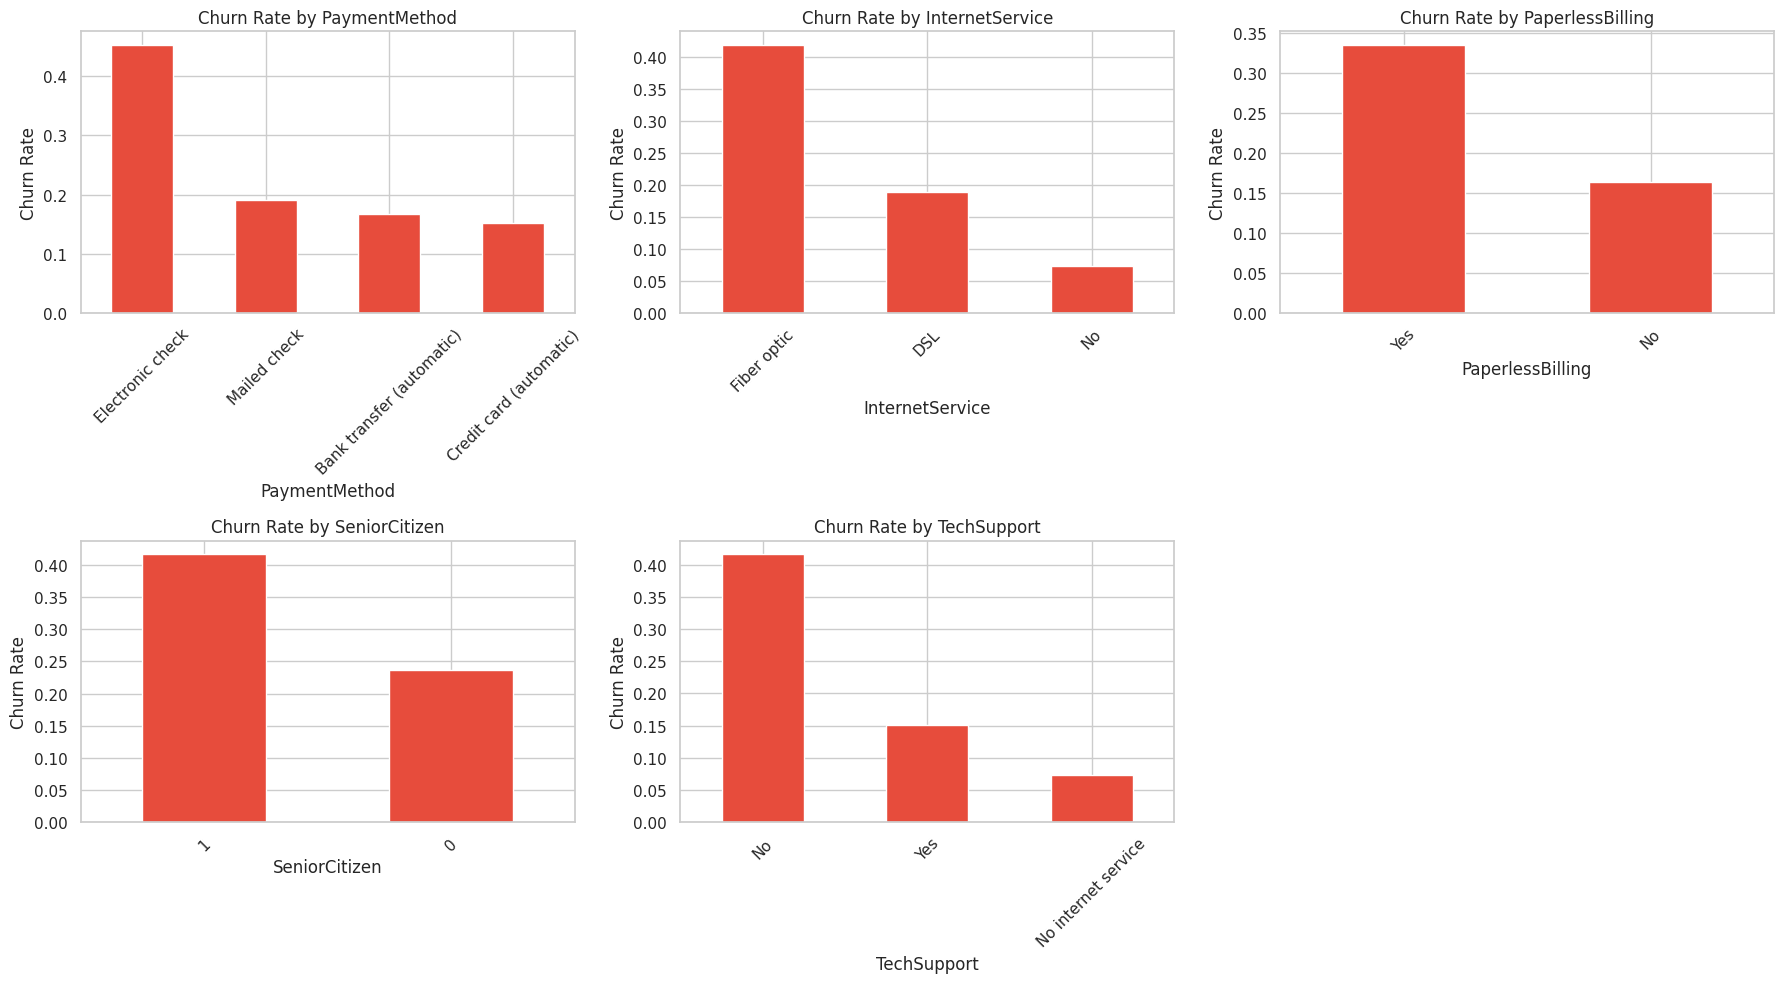

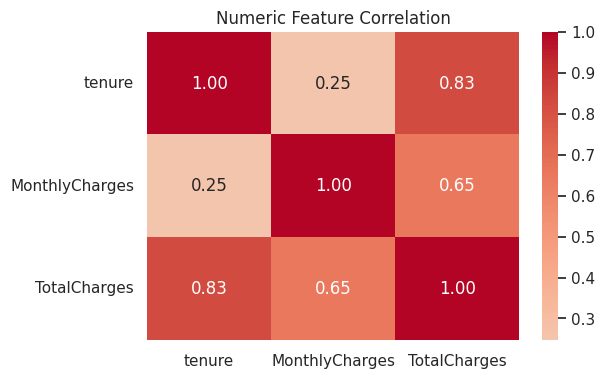

In [16]:
# Let's explore how certain categorical features affect the churn RATE (not raw count).
# We look at rates because comparing raw counts is misleading if groups are different sizes.
cat_cols_to_check = ['PaymentMethod', 'InternetService', 'PaperlessBilling', 'SeniorCitizen', 'TechSupport']

# Create a grid of subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Loop through our categorical columns and plot them one by one
for ax, col in zip(axes.flat, cat_cols_to_check):
    # Calculate the average churn (which equals the churn rate since Churn is 1 or 0)
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)

    # Plot as a bar chart
    churn_rate.plot(kind='bar', ax=ax, color='#E74C3C')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate')
    # Make x-axis labels readable by rotating them
    ax.tick_params(axis='x', rotation=45)

# Hide the 6th empty subplot (since we only have 5 columns to check)
axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

# CORRELATION HEATMAP FOR NUMERIC FEATURES
# We check this to ensure features aren't perfectly predicting each other (multicollinearity).
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(6, 4))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Numeric Feature Correlation')
plt.show()

# Notice the high correlation (~0.83) between TotalCharges and tenure.
# Because TotalCharges is basically just (tenure * MonthlyCharges), keeping it dilutes
# our model's understanding. We will drop TotalCharges in the next step.

### Advanced Feature Engineering & Train/Test Split

In [17]:
# Create a copy of the dataframe to safely apply our engineering steps
df_engineered = df.copy()

# 1. COLLAPSE REDUNDANT CATEGORIES
# 'No internet service' and 'No phone service' are redundant because we already have columns
# telling us if they have internet or phone. We simplify these to just 'No'.
no_service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                   'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']
for col in no_service_cols:
    df_engineered[col] = df_engineered[col].replace(
        {'No internet service': 'No', 'No phone service': 'No'}
    )

# 2. CREATE NEW INSIGHTFUL FEATURES
# Spending Intensity: How much are they paying relative to how long they've been here?
# We add +1 to tenure to avoid dividing by zero for brand new customers.
df_engineered['Spending_Intensity'] = df_engineered['MonthlyCharges'] / (df_engineered['tenure'] + 1)

# Contract Ordinal: Month-to-month is less commitment than 1 year, which is less than 2 years.
# We map these to 0, 1, and 2 to preserve this natural order instead of treating them as unrelated categories.
contract_order = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df_engineered['Contract_Ordinal'] = df_engineered['Contract'].map(contract_order)

# High-Risk Interaction: Month-to-Month contract PLUS Electronic check payment is a known flight risk.
# This creates a binary column: 1 if both conditions are met, 0 otherwise.
df_engineered['MTM_ElectronicCheck'] = (
    (df_engineered['Contract'] == 'Month-to-month') &
    (df_engineered['PaymentMethod'] == 'Electronic check')
).astype(int)

# 3. DROP REDUNDANT/REPLACED COLUMNS
# TotalCharges correlates too highly with tenure (multicollinearity).
# Contract was replaced by Contract_Ordinal.
df_engineered = df_engineered.drop(['TotalCharges', 'Contract'], axis=1)

# 4. SEPARATE FEATURES AND TARGET
X = df_engineered.drop('Churn', axis=1)
y = df_engineered['Churn']

# 5. STRATIFIED TRAIN-TEST SPLIT
# We split the data BEFORE doing one-hot encoding to prevent data leakage.
# stratify=y ensures both our training and testing data maintain the exact same 26.5% churn ratio.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (5634, 20)
Testing features shape: (1409, 20)


### Robust Preprocessing Pipeline Setup

In [18]:
# Identify which columns are categorical (text) and which are numeric.
# We treat our engineered columns ('Contract_Ordinal', 'MTM_ElectronicCheck') as numeric here
# because they are already converted to ordered numbers.
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()
numeric_features = X_train.select_dtypes(exclude=['object']).columns.tolist()

# Define the transformation steps for numeric data.
# StandardScaler centers data around 0. Useful for some models, though LightGBM handles unscaled data well.
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Define the transformation steps for categorical data.
# OneHotEncoder creates binary columns for each category (e.g., gender_Male, gender_Female).
# handle_unknown='ignore' ensures the pipeline doesn't break if future data has a new, unseen category.
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Combine both transformations into a single ColumnTransformer.
# This will apply the numeric scaling to numeric columns, and encoding to categorical columns simultaneously.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Preprocessing pipeline steps defined.")

Preprocessing pipeline steps defined.


### Modeling: LightGBM and Hyperparameter Tuning

In [19]:
# Create the full modeling pipeline: First it preprocesses the data, then it trains a LightGBM model.
# LightGBM is generally faster and more accurate on tabular data than Random Forest.
# class_weight='balanced' automatically handles our 26.5% minority churn class!
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(class_weight='balanced', random_state=42, force_row_wise=True))
])

# Define the hyperparameter grid we want to search over.
# These parameters control how the tree grows and learns, helping prevent overfitting.
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [3, 5, 7, -1],
    'classifier__num_leaves': [15, 31, 50],
    'classifier__subsample': [0.7, 0.8, 1.0]
}

# Use RandomizedSearchCV to find the best combination of parameters.
# n_iter=40 tests 40 different combinations.
# scoring='average_precision' tells it to optimize for PR-AUC (best for imbalanced data).
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=40,
    cv=5,
    scoring='average_precision',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

print("Tuning LightGBM Model... This will take a moment.")
random_search.fit(X_train, y_train)

# Save the absolute best model found during the search
best_model = random_search.best_estimator_

print("\nBest Hyperparameters found:")
# We strip the 'classifier__' prefix just to make it easier to read
for k, v in random_search.best_params_.items():
    print(f"{k.replace('classifier__', '')}: {v}")

Tuning LightGBM Model... This will take a moment.
Fitting 5 folds for each of 40 candidates, totalling 200 fits
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Total Bins 628
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

### Evaluation: PR-AUC & Threshold Tuning

ROC-AUC Score: 0.8399
PR-AUC (Average Precision) Score: 0.6558

Optimal Custom Threshold to catch >=75% of Churners: 0.5375

--- Classification Report (Tuned Threshold) ---
              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1035
           1       0.53      0.76      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


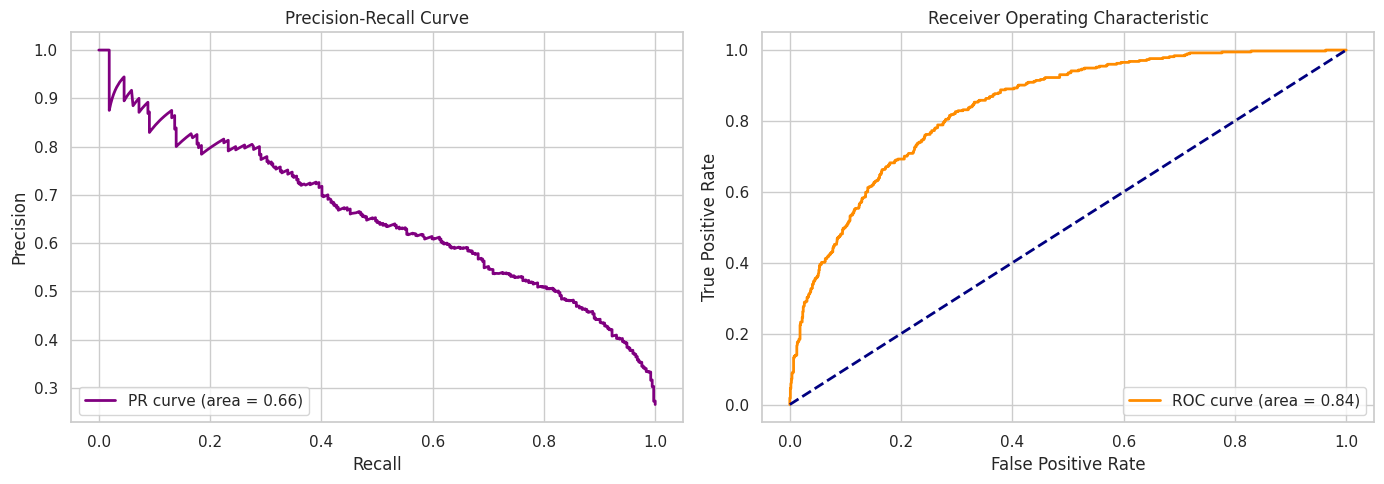

In [20]:
# Get predictions and probabilities from the best model
y_pred_default = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# 1. EVALUATE PR-AUC (Better than ROC-AUC for imbalanced datasets)
# PR-AUC focuses specifically on how well the model identifies the minority class (Churn).
pr_auc = average_precision_score(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"PR-AUC (Average Precision) Score: {pr_auc:.4f}\n")

# 2. THRESHOLD TUNING
# By default, models predict churn if probability > 0.5.
# But missing a churner (False Negative) is usually costlier than a False Positive.
# Let's find the exact probability threshold that captures at least 75% of actual churners (Recall >= 0.75).
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# Create a dataframe to easily search the thresholds
pr_df = pd.DataFrame({'precision': precisions[:-1], 'recall': recalls[:-1], 'threshold': thresholds})
# Filter for thresholds that give us a recall of at least 75%, then sort by best precision
best_threshold_row = pr_df[pr_df['recall'] >= 0.75].sort_values(by='precision', ascending=False).iloc[0]
optimal_threshold = best_threshold_row['threshold']

print(f"Optimal Custom Threshold to catch >=75% of Churners: {optimal_threshold:.4f}")

# Apply the custom threshold
y_pred_tuned = (y_prob >= optimal_threshold).astype(int)
print("\n--- Classification Report (Tuned Threshold) ---")
print(classification_report(y_test, y_pred_tuned))

# 3. PLOT CURVES
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Precision-Recall Curve
ax[0].plot(recalls, precisions, color='purple', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
ax[0].set_xlabel('Recall')
ax[0].set_ylabel('Precision')
ax[0].set_title('Precision-Recall Curve')
ax[0].legend(loc="lower left")

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('Receiver Operating Characteristic')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

### Business Insights Using SHAP

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


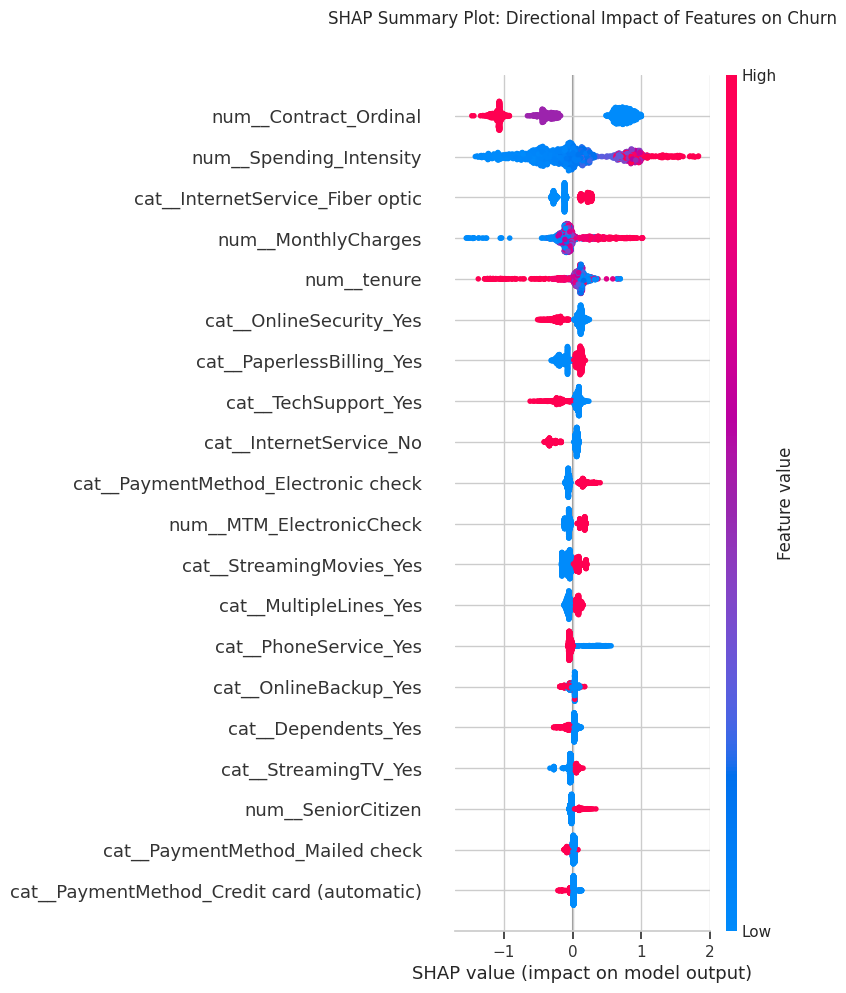


EXECUTIVE BUSINESS SUMMARY (Powered by SHAP Insights)

1. CONTRACT MATURITY & TENURE ARE PARAMOUNT:
   The SHAP plot reveals that low values (blue dots) for Contract_Ordinal and Tenure 
   push the churn prediction heavily to the right (higher risk). 
   Strategy: Front-load retention budgets. Offer aggressive discounts at month 1 
   to transition Month-to-Month users into 1-year commitments.

2. THE "MONTH-TO-MONTH + ELECTRONIC CHECK" DANGER ZONE:
   Our engineered interaction feature (MTM_ElectronicCheck) shows up strongly. Customers 
   in this bucket have a significantly elevated baseline churn risk.
   Strategy: Nudge MTM Electronic Check users toward auto-pay (Credit Card/Bank Transfer) 
   by offering a small monthly auto-pay discount.

3. SPENDING INTENSITY MATTERS:
   High MonthlyCharges (red dots) push predictions to the right, indicating price sensitivity.
   Strategy: For accounts flagged as high-risk by the model where MonthlyCharges is high, 
   proactively offer "loyal

In [22]:
# To use SHAP effectively with a Pipeline, we need to manually process the test data
# so SHAP can see the final, transformed feature names and values.

# 1. Transform the test data using our fitted preprocessor
X_test_transformed = best_model.named_steps['preprocessor'].transform(X_test)

# 2. Retrieve the names of the columns after preprocessing (e.g., one-hot encoding creates new names)
# get_feature_names_out() pulls the exact names created by the ColumnTransformer
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

# Create a clean dataframe for SHAP to use
X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names)

# Extract the trained LightGBM classifier from the pipeline
lgbm_model = best_model.named_steps['classifier']

# 3. Initialize the SHAP TreeExplainer and calculate SHAP values
# SHAP calculates exactly how much each feature contributed to pushing a prediction towards or away from Churn.
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test_shap)

# 4. Plot the SHAP Summary Plot
# - The y-axis shows features ordered by importance.
# - The x-axis shows the SHAP value (impact on model output: right means higher risk of churn).
# - Color shows the original value of the feature (red = high value, blue = low value).
plt.figure(figsize=(10, 6))

# --- FIX IMPLEMENTED HERE ---
# Handle SHAP version differences: older versions return a list of arrays for binary classification,
# while newer versions return a single array.
if isinstance(shap_values, list):
    plot_values = shap_values[1]
else:
    plot_values = shap_values

shap.summary_plot(plot_values, X_test_shap, show=False)
# ----------------------------

plt.title("SHAP Summary Plot: Directional Impact of Features on Churn", y=1.05)
plt.show()

# 5. EXECUTIVE BUSINESS SUMMARY PRINT-OUT
print("\n" + "="*60)
print("EXECUTIVE BUSINESS SUMMARY (Powered by SHAP Insights)")
print("="*60)

print("""
1. CONTRACT MATURITY & TENURE ARE PARAMOUNT:
   The SHAP plot reveals that low values (blue dots) for Contract_Ordinal and Tenure
   push the churn prediction heavily to the right (higher risk).
   Strategy: Front-load retention budgets. Offer aggressive discounts at month 1
   to transition Month-to-Month users into 1-year commitments.

2. THE "MONTH-TO-MONTH + ELECTRONIC CHECK" DANGER ZONE:
   Our engineered interaction feature (MTM_ElectronicCheck) shows up strongly. Customers
   in this bucket have a significantly elevated baseline churn risk.
   Strategy: Nudge MTM Electronic Check users toward auto-pay (Credit Card/Bank Transfer)
   by offering a small monthly auto-pay discount.

3. SPENDING INTENSITY MATTERS:
   High MonthlyCharges (red dots) push predictions to the right, indicating price sensitivity.
   Strategy: For accounts flagged as high-risk by the model where MonthlyCharges is high,
   proactively offer "loyalty bundles" that lower their perceived per-service cost.
""")